Name: Prajakta Vishwajit Mahangare

Class:CSE(AI) SY(SEDA)

Rollno. 34  PRN NO. 12520047

Assignment no.13

 Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Load Dataset

In [ ]:
df = pd.read_csv("Iris.csv")
print(df.head())
print(df.info())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


Check Missing Values

In [ ]:
print(df.isnull().sum())

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df = df.drop(columns=['Id'])

Feature Selection

In [ ]:
X = df.drop(columns=['Species'])

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Data Visualization

Pairplot

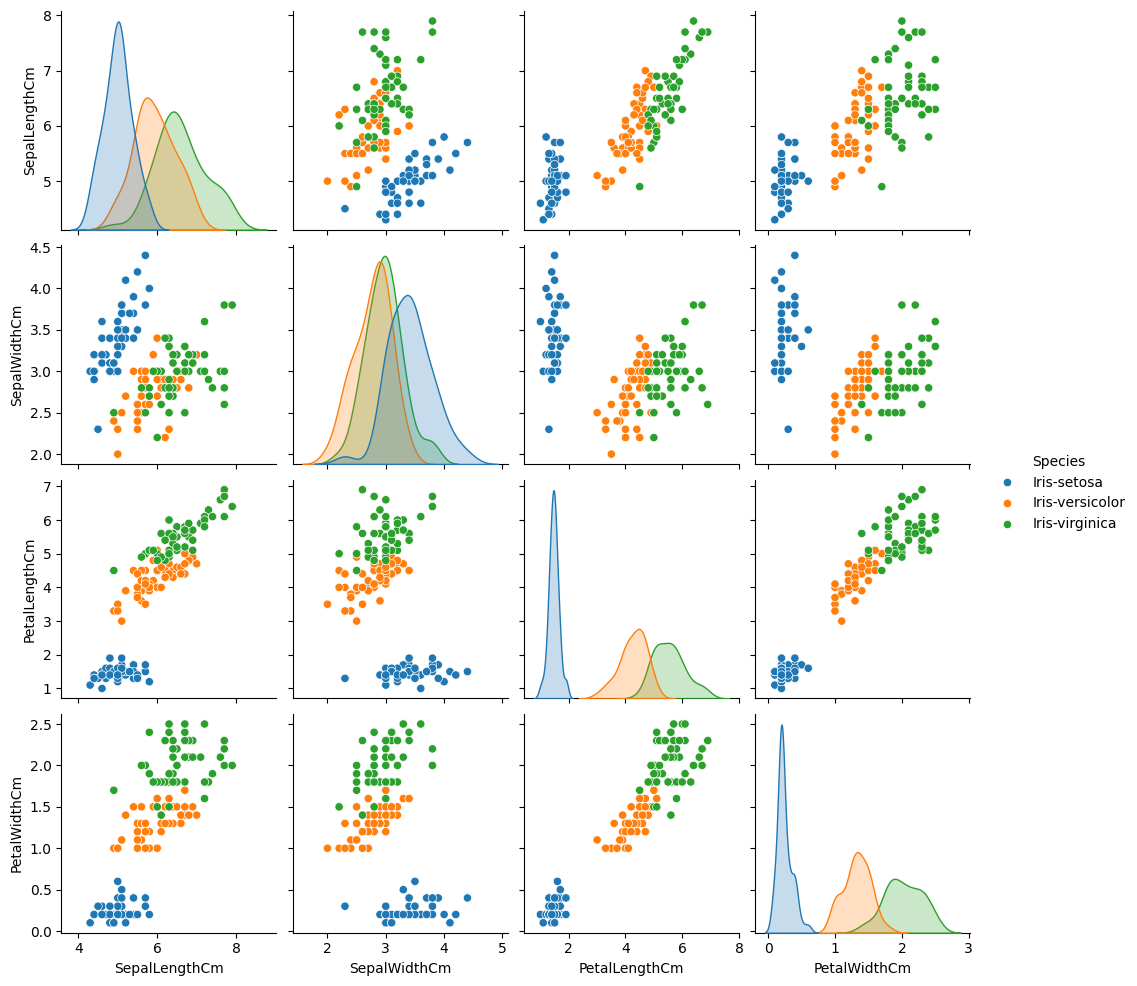

In [ ]:
sns.pairplot(df, hue='Species')
plt.show()

Correlation Heatmap

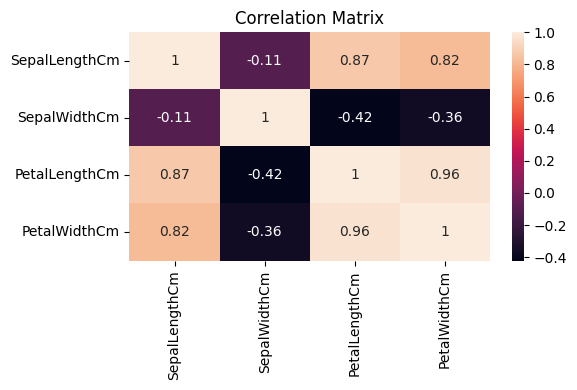

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Elbow Method

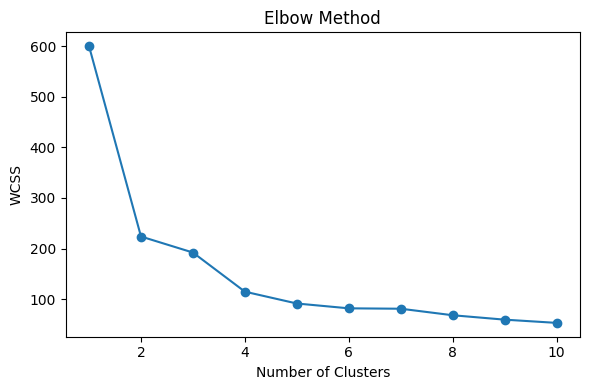

In [ ]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.tight_layout()
plt.show()

Apply K-Means Algorithm

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [ ]:
df["Cluster"] = y_kmeans
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,2
2,4.7,3.2,1.3,0.2,Iris-setosa,2
3,4.6,3.1,1.5,0.2,Iris-setosa,2
4,5.0,3.6,1.4,0.2,Iris-setosa,1


Visualization of Clusters

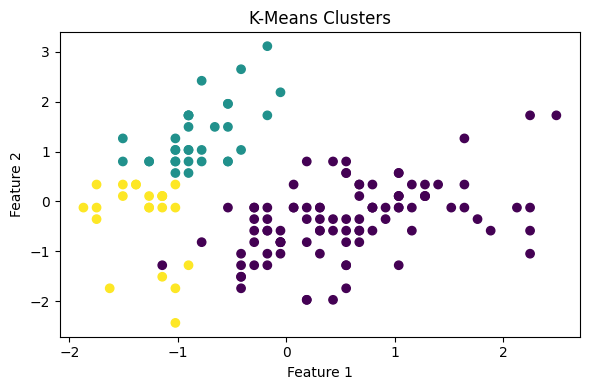

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans, cmap='viridis')
plt.title("K-Means Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()

Centroid Visualization

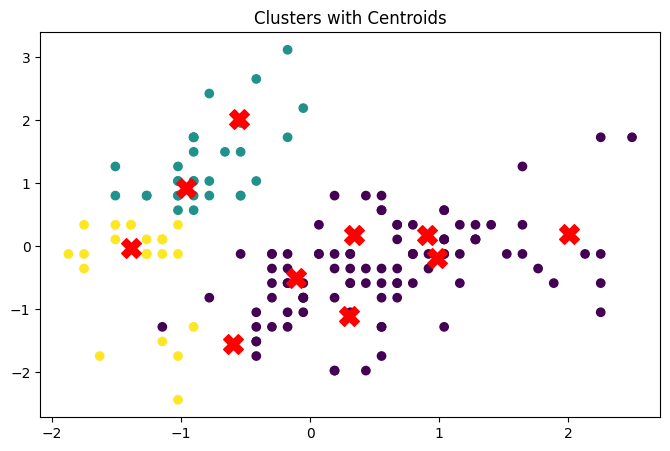

In [ ]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X')
plt.title("Clusters with Centroids")
plt.show()

Compare with Actual Species

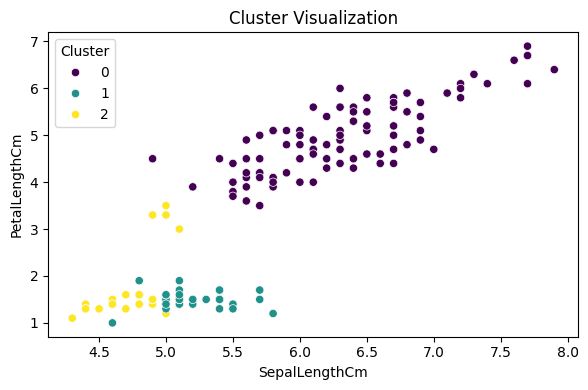

In [ ]:
df['Cluster'] = y_kmeans

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['SepalLengthCm'], y=df['PetalLengthCm'],
                hue=df['Cluster'], palette='viridis')
plt.title("Cluster Visualization")
plt.tight_layout()
plt.show()

Cluster Centers

In [ ]:
print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[ 0.57100359 -0.36600236  0.69108416  0.66322635]
 [-0.80601877  1.33577362 -1.28618375 -1.21026347]
 [-1.31926109 -0.34584225 -1.14482725 -1.1336954 ]]


Model Evaluation

Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.4787241921049546
